# Optical Flow Tracker

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [21]:
# Load two consecutive images (grayscale)
img1 = cv2.imread("C:/Meet/PDEU/Semester 7/Computer Vision Lab/Computer-Vision/Images/Optical Flow Tracker Images/car1.jpg")
img2 = cv2.imread("C:/Meet/PDEU/Semester 7/Computer Vision Lab/Computer-Vision/Images/Optical Flow Tracker Images/car2.jpg")

In [22]:
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

In [23]:
# Step 1: Shi-Tomasi Corner Detection parameters
feature_params = dict(maxCorners=200,
                      qualityLevel=0.3,
                      minDistance=7,
                      blockSize=7)

# Detect features in the first image
p0 = cv2.goodFeaturesToTrack(gray1, mask=None, **feature_params)

In [24]:
# Step 2: Lucas-Kanade Optical Flow parameters
lk_params = dict(winSize=(15, 15),
                 maxLevel=2,
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

In [25]:
# Step 3: Calculate Optical Flow (track points from img1 → img2)
p1, st, err = cv2.calcOpticalFlowPyrLK(gray1, gray2, p0, None, **lk_params)

In [26]:
# Select good points
good_new = p1[st == 1]
good_old = p0[st == 1]

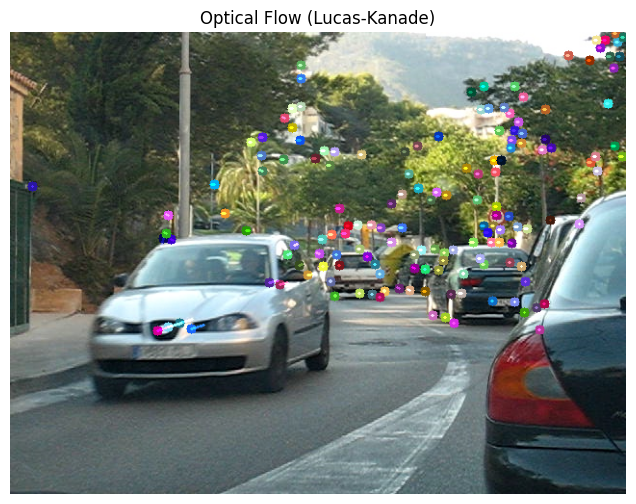

In [27]:
# Step 4: Draw the tracks
mask = np.zeros_like(img1)
color = np.random.randint(0, 255, (len(good_new), 3))  # FIX: match number of points

# Convert BGR (OpenCV) → RGB (matplotlib)
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(output_rgb)
plt.axis("off")
plt.title("Optical Flow (Lucas-Kanade)")
plt.show()